# 06 Model Evaluation and Interpretation

This notebook evaluates the competing models against the stakeholder goal of identifying likely inspections and interprets the strongest drivers of inspection likelihood.

In [9]:
# Author: Jessica
# Loading saved model outputs so this notebook runs independently

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

model_results = pd.read_csv("shared_data/model_results_summary.csv")
importance = pd.read_csv("shared_data/feature_importance.csv")
predictions_df = pd.read_csv("shared_data/model_predictions.csv")

print(model_results)
importance.head()

                          Model  Accuracy  Precision_Inspection  \
0           Logistic Regression  0.797935              0.595339   
1  Balanced Logistic Regression  0.733815              0.435394   
2                 Random Forest  0.811771              0.619665   

   Recall_Inspection  F1_Inspection  
0           0.262985       0.364817  
1           0.695367       0.535495  
2           0.380440       0.471441  


,feature,coefficient
0,time_since_open_days,1.216325
1,historical_avg_score,0.680312
2,critical_violations,0.580422
3,total_violations,0.372821
4,zip_inspections_per_restaurant,0.269555


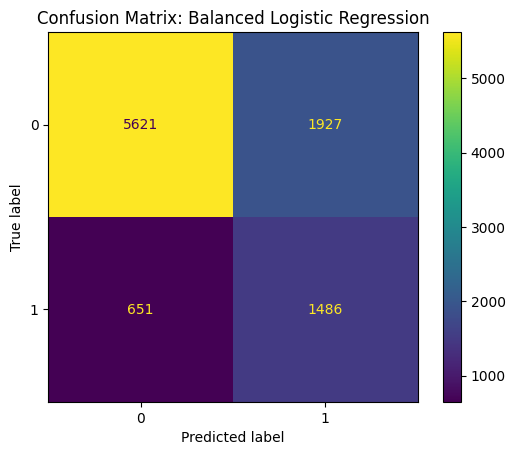

In [10]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions_df = pd.read_csv("shared_data/model_predictions.csv")

cm = confusion_matrix(
    predictions_df['y_test'],
    predictions_df['balanced_logistic_pred']
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix: Balanced Logistic Regression")
plt.show()

The confusion matrix shows the model captures most inspection cases while allowing some false positives, which is acceptable since the goal is to help restaurants prepare for potential inspections

In [11]:
# Author: Jessica
# Loading feature importance from modeling notebook so this notebook runs independently

import pandas as pd

importance = pd.read_csv("shared_data/feature_importance.csv")

print(importance)

                           feature  coefficient
0             time_since_open_days     1.216325
1             historical_avg_score     0.680312
2              critical_violations     0.580422
3                 total_violations     0.372821
4   zip_inspections_per_restaurant     0.269555
5       score_change_from_previous     0.229716
6                 inspection_month     0.102099
7                         latitude     0.075633
8          median_household_income     0.055175
9                    boro_Brooklyn     0.044536
10          prior_inspection_count     0.036033
11                poverty_rate_pct     0.034594
12                   zip_avg_score     0.030621
13                     boro_Queens     0.026546
14    population_density_per_sq_mi     0.011027
15              boro_Staten Island    -0.000909
16            zip_restaurant_count    -0.004108
17                  boro_Manhattan    -0.013654
18                      boro_Bronx    -0.026361
19                       longitude    -0

Prior inspections and recent violations are the strongest drivers of future inspections, suggesting inspection decisions are based more on recent activity than long-term trends

## Confusion Matrix for Random Forest

We're running a confusion matrix for a random forest classifier

Random Forest Confusion Matrix:
 [[7049  499]
 [1324  813]]


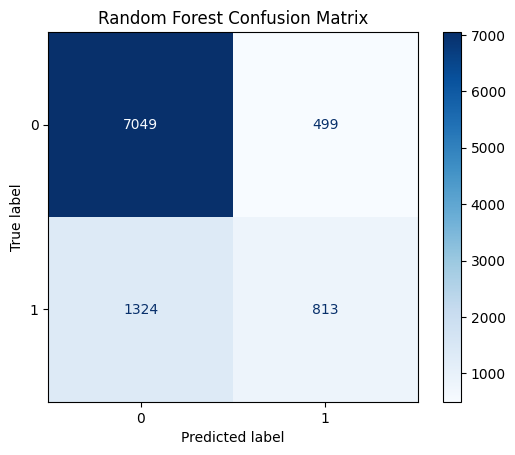

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict with trained Random Forest model
predictions_df = pd.read_csv("shared_data/model_predictions.csv")

# Build confusion matrix
# Use 'random_forest_pred' column from saved predictions
cm_rf = confusion_matrix(
    predictions_df['y_test'],
    predictions_df['random_forest_pred']
)
print("Random Forest Confusion Matrix:\n", cm_rf)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues", values_format="d")
plt.title("Random Forest Confusion Matrix")
plt.show()